In [205]:
import sys
import os

# Add parent directory to path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle

from src.config_loader import load_config
from src.data_loader import load_calhoun_soil_moisture
from src.gradient_based_sampling import (
    gradient_based_sampling,
    visualize_gradient_sampling,
    compute_gradient_weights
)
from src.normalization_helper import NormalizationHelper

print("✓ Modules loaded")

✓ Modules loaded


In [206]:
config = load_config('../configs/baseline.yaml')
config.print_summary()

device = torch.device(config.device)
print(f"\nDevice: {device}")

torch.manual_seed(config.seed)
np.random.seed(config.seed)

CONFIGURATION SUMMARY
Config file: ../configs/baseline.yaml

Data:
  Path: data/2017_HalfHourly_UTC_ForestSite1.xlsx
  Date range: 2017-05-1 to 2017-05-19

Training:
  Epochs: 10000
  Learning rate: 0.0001
  Device: cpu
  Seed: 44

Network:
  h_net: {'hidden_dim': 64, 'num_layers': 4}
  zb_net: {'hidden_dim': 32, 'num_layers': 3}

Cache Pool & Batch Sampling:
  Cache size: 10000
  Batch size: 500
  Resample freq: 10000
  Boundary ratio: 0.7
  High residual ratio: 0.6
  Temperature: 0.3

Boundary Sampling (Gradient-based):
  Batch size BC: 450
  Interp ratio: 0.3
  Neighbor ratio: 0.0
  Baseline ratio: 0.7
  Gradient threshold: 0.7
  Gradient power: 2.0

Optimization:
  Weight update freq: 10000000000.0
  Use AMP: False
  Use multi-GPU: True

Physics:
  Sy: 0.3, zr: 0.5
  L: 4.0, S_max: 1e-07
  zb_initial: 6.1
  IC type: obs

Checkpointing:
  Directory: checkpoints_train
  Frequency: 10000

Output:
  Directory: outputs

Device: cpu


In [207]:
print("="*70)
print("STEP 1: LOADING SOIL MOISTURE DATA")
print("="*70)

project_root = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
data_path = os.path.join(project_root, config.data_path)

print(f"Data file: {data_path}")
print(f"Date range: {config.start_date} to {config.end_date}")

soil_data = load_calhoun_soil_moisture(
    filepath=data_path,
    interpolate=config.interpolate,
    max_gap_hours=config.max_gap_hours,
    start_date=config.start_date,
    end_date=config.end_date,
    verbose=True
)

datetime_col = soil_data['datetime']
times_seconds = soil_data['times_seconds']
theta_2cm = soil_data['theta_2cm']
theta_15cm = soil_data['theta_15cm']
theta_30cm = soil_data['theta_30cm']
theta_40cm = soil_data['theta_40cm']
theta_60cm = soil_data['theta_60cm']
theta_80cm = soil_data['theta_80cm']

print(f"\n✓ Data loaded:")
print(f"  Total time points: {len(times_seconds)}")
print(f"  Duration: {times_seconds[-1]/86400:.2f} days")
print(f"  Surface moisture range: {np.nanmin(theta_2cm):.4f} - {np.nanmax(theta_2cm):.4f} m³/m³")

STEP 1: LOADING SOIL MOISTURE DATA
Data file: /Users/jasonjing/Documents/smap/SMAP-Recharge-Flux/data/2017_HalfHourly_UTC_ForestSite1.xlsx
Date range: 2017-05-1 to 2017-05-19
LOADING CALHOUN SOIL MOISTURE DATA

Data loaded:
  Total records: 17521
  Time range: 2017-01-01 01:00:00 to 2018-01-01 00:00:00
  Duration: ~364 days
  Resolution: 30 minutes

REPLACING MISSING VALUE CODES (-9999) WITH NaN
Missing value codes replaced with NaN

Time period selection (date-based):
  Start date: 2017-05-01 00:00:00
  End date:   2017-05-19 00:00:00
  Selected:   865 points
  Date range: 2017-05-01 00:00:00 to 2017-05-19 00:00:00
  Duration:   18.0 days

Raw data quality (after replacing -9999 with NaN):
----------------------------------------------------------------------
2cm   :   865 valid,     0 NaN ( 0.00%), range=[0.0794, 0.1979]
15cm  :   865 valid,     0 NaN ( 0.00%), range=[0.1372, 0.2342]
30cm  :   865 valid,     0 NaN ( 0.00%), range=[0.1342, 0.2572]
40cm  :   865 valid,     0 NaN ( 0.00

STEP 2: VISUALIZING INTERPOLATION QUALITY (SURFACE LAYER)


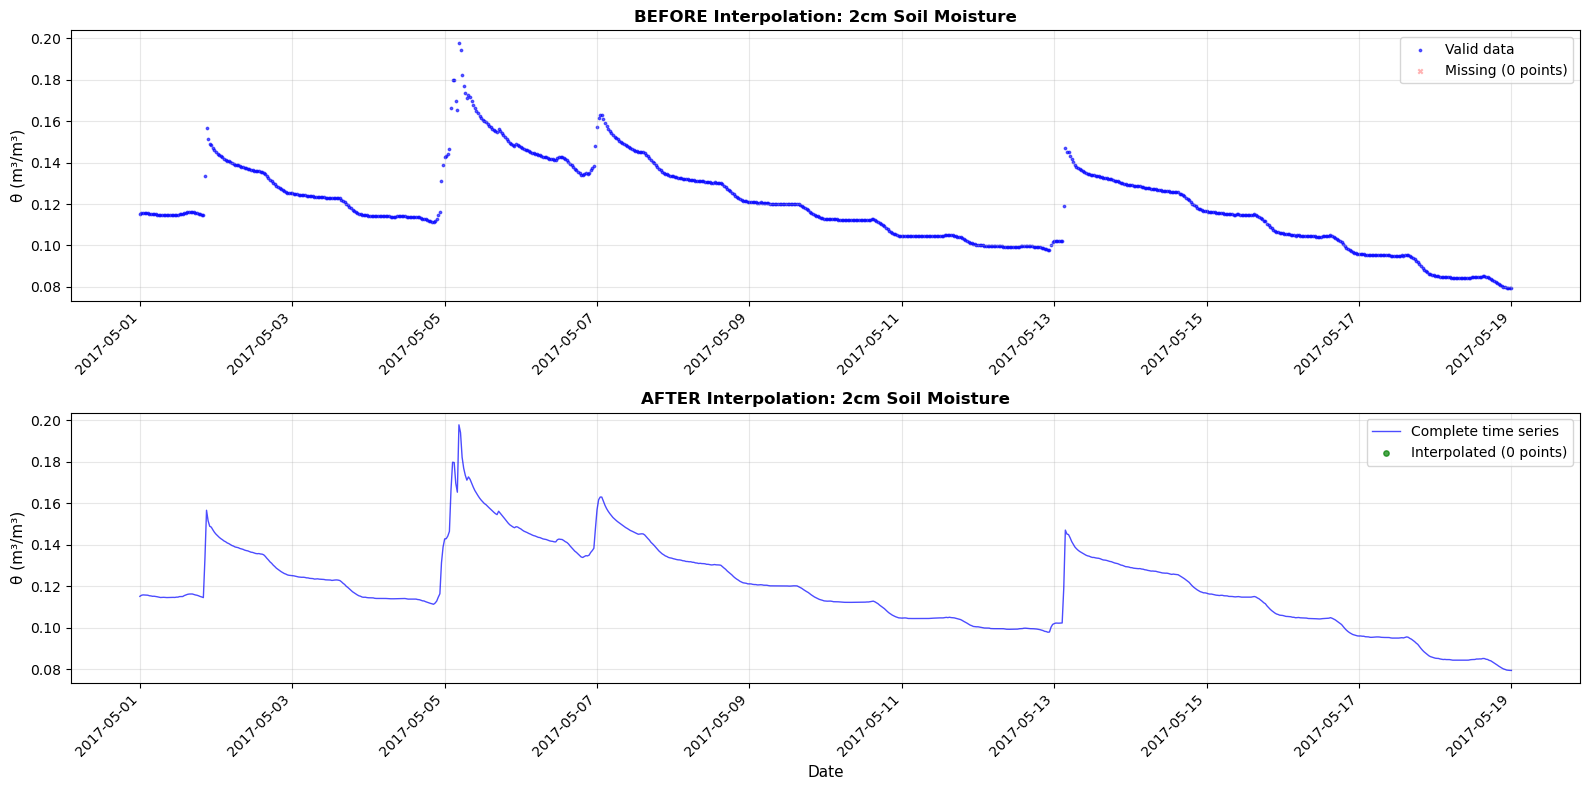


✓ Interpolation Quality:
  Original valid points: 865
  Missing values: 0
  Points interpolated: 0
  Data completeness: 100.0%


In [208]:
print("="*70)
print("STEP 2: VISUALIZING INTERPOLATION QUALITY (SURFACE LAYER)")
print("="*70)

theta_2cm_raw = soil_data['raw_data'][0]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

ax1 = axes[0]
valid_mask = ~pd.isna(theta_2cm_raw)
ax1.scatter(datetime_col[valid_mask], theta_2cm_raw[valid_mask],
           s=3, alpha=0.6, color='blue', label='Valid data')
ax1.scatter(datetime_col[~valid_mask], np.full((~valid_mask).sum(), np.nanmean(theta_2cm_raw)),
           s=10, alpha=0.3, color='red', marker='x',
           label=f'Missing ({(~valid_mask).sum()} points)')
ax1.set_ylabel('θ (m³/m³)', fontsize=11)
ax1.set_title('BEFORE Interpolation: 2cm Soil Moisture', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2 = axes[1]
still_nan_mask = pd.isna(theta_2cm)
filled_mask = pd.isna(theta_2cm_raw) & ~pd.isna(theta_2cm)
n_filled_2cm = soil_data['interpolation_stats']['2cm']['n_filled']

ax2.plot(datetime_col, theta_2cm, linewidth=1, alpha=0.7, color='blue', label='Complete time series')
ax2.scatter(datetime_col[filled_mask], theta_2cm[filled_mask],
           s=15, alpha=0.7, color='green', marker='o',
           label=f'Interpolated ({n_filled_2cm} points)', zorder=5)
if still_nan_mask.any():
    ax2.scatter(datetime_col[still_nan_mask], np.full(still_nan_mask.sum(), np.nanmean(theta_2cm)),
               s=20, alpha=0.5, color='red', marker='x',
               label=f'Still missing ({still_nan_mask.sum()})', zorder=5)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('θ (m³/m³)', fontsize=11)
ax2.set_title('AFTER Interpolation: 2cm Soil Moisture', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\n✓ Interpolation Quality:")
print(f"  Original valid points: {(~pd.isna(theta_2cm_raw)).sum()}")
print(f"  Missing values: {(pd.isna(theta_2cm_raw)).sum()}")
print(f"  Points interpolated: {n_filled_2cm}")
print(f"  Data completeness: {soil_data['interpolation_stats']['2cm']['completeness']:.1f}%")

STEP 3: TESTING GRADIENT-BASED SAMPLING

✓ Gradient Statistics:
  Max |dθ/dt|:  1.807e-05 m³/m³/s
  Mean |dθ/dt|: 3.271e-07 m³/m³/s
  Min |dθ/dt|:  0.000e+00 m³/m³/s

✓ Generated 450 gradient-weighted samples:
  Interpolated: 135 (30.0%)
  Neighbors:    0 (0.0%)
  Baseline:     315 (70.0%)


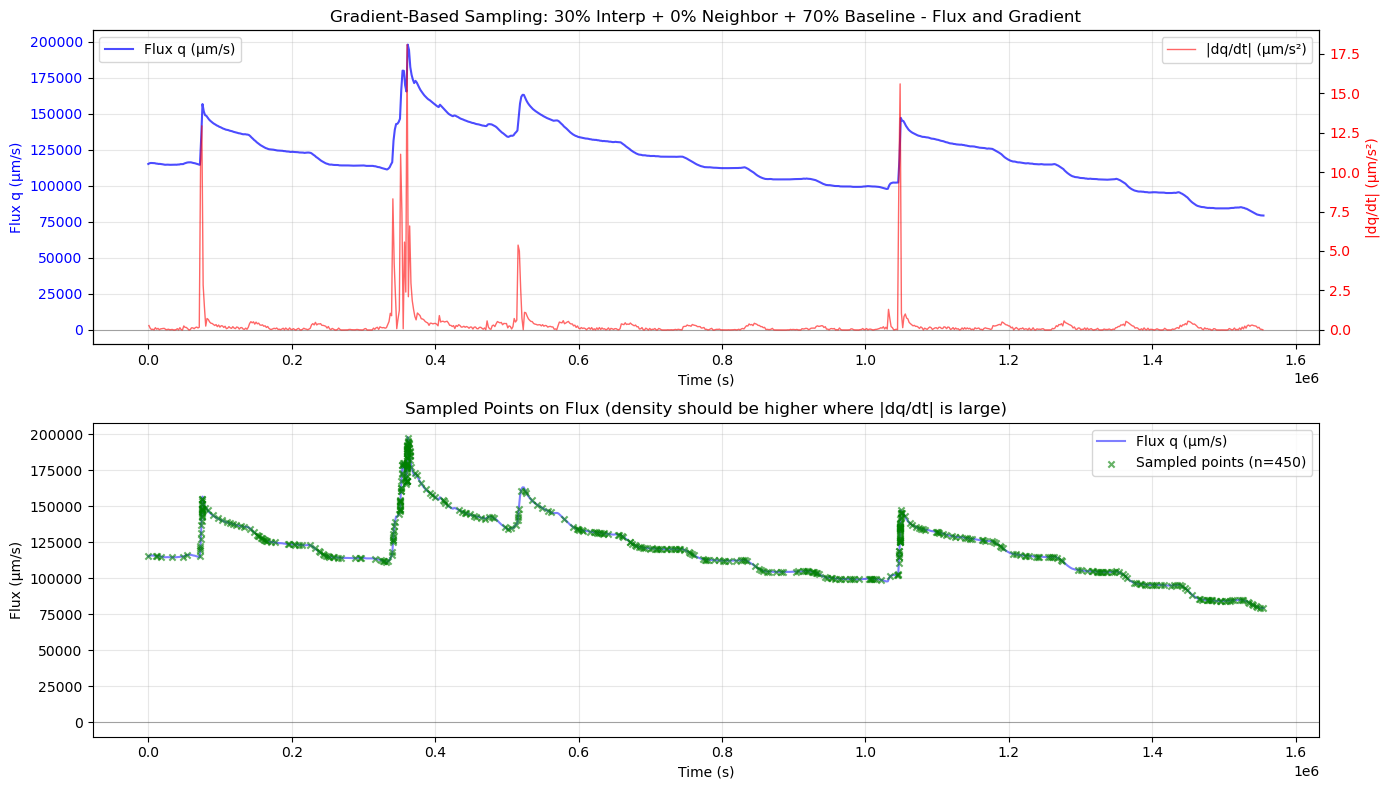

In [209]:
print("="*70)
print("STEP 3: TESTING GRADIENT-BASED SAMPLING")
print("="*70)

valid_mask = ~pd.isna(theta_2cm)
theta0_times = times_seconds[valid_mask]
theta0_values = theta_2cm[valid_mask]

theta0_times_np = np.array(theta0_times, dtype=np.float64)
theta0_values_np = np.array(theta0_values, dtype=np.float64)

theta0_times_t = torch.tensor(theta0_times_np, dtype=torch.float32).to(device)
theta0_values_t = torch.tensor(theta0_values_np, dtype=torch.float32).to(device)

gradient_weights, gradients = compute_gradient_weights(theta0_times_t, theta0_values_t, device)

grad_abs = gradients.abs()
print(f"\n✓ Gradient Statistics:")
print(f"  Max |dθ/dt|:  {grad_abs.max().item():.3e} m³/m³/s")
print(f"  Mean |dθ/dt|: {grad_abs.mean().item():.3e} m³/m³/s")
print(f"  Min |dθ/dt|:  {grad_abs.min().item():.3e} m³/m³/s")

t_bc_gradient, sample_info = gradient_based_sampling(
    theta0_times_t,
    theta0_values_t,
    config.batch_size_bc,
    device=device,
    use_interpolation=True,
    interp_ratio=config.interp_ratio,
    neighbor_ratio=config.neighbor_ratio,
    baseline_ratio=config.baseline_ratio,
    neighbor_expansion=config.gradient_neighbor_expansion,
    gradient_threshold=config.gradient_threshold,
    power=config.gradient_power
)

print(f"\n✓ Generated {len(t_bc_gradient)} gradient-weighted samples:")
print(f"  Interpolated: {sample_info['n_interp_samples']} ({sample_info['actual_ratios']['interp']*100:.1f}%)")
print(f"  Neighbors:    {sample_info['n_neighbor_samples']} ({sample_info['actual_ratios']['neighbor']*100:.1f}%)")
print(f"  Baseline:     {sample_info['n_baseline_samples']} ({sample_info['actual_ratios']['baseline']*100:.1f}%)")

visualize_gradient_sampling(
    theta0_times_t,
    theta0_values_t,
    t_bc_gradient,
    sample_info,
    title=f'Gradient-Based Sampling: {config.interp_ratio*100:.0f}% Interp + {config.neighbor_ratio*100:.0f}% Neighbor + {config.baseline_ratio*100:.0f}% Baseline'
)
plt.show()

In [210]:
print("="*70)
print("STEP 4: TESTING SOIL PARAMETERS (Se, h, K(h))")
print("="*70)

normalizer = NormalizationHelper(config.soil_params, L=config.L, S_max=config.S_max)

print(f"Soil parameters:")
for key, val in config.soil_params.items():
    print(f"  {key}: {val}")

theta_depths = {
    '2cm': theta_2cm,
    '15cm': theta_15cm,
    '30cm': theta_30cm,
    '40cm': theta_40cm,
    '60cm': theta_60cm,
    '80cm': theta_80cm,
}

colors = ['#e41a1c', '#ff7f00', '#ffff33', '#4daf4a', '#377eb8', '#984ea3']
depth_names = ['2cm', '15cm', '30cm', '40cm', '60cm', '80cm']

all_results = {}

for depth_name in depth_names:
    theta_vals = theta_depths[depth_name]
    
    valid_mask = ~pd.isna(theta_vals)
    times_sec = times_seconds[valid_mask]
    theta_clean = theta_vals[valid_mask]
    
    times_sec = np.array(times_sec, dtype=np.float64)
    theta_clean = np.array(theta_clean, dtype=np.float64)
    
    if len(theta_clean) == 0:
        print(f"  Warning: No valid data for {depth_name}")
        continue
    
    theta_r = normalizer.theta_r
    theta_star = normalizer.theta_star
    Se_obs = np.clip((theta_clean - theta_r) / theta_star, 1e-6, 1.0 - 1e-6)
    
    alpha_tilde = normalizer.alpha_tilde
    n_vg = normalizer.n
    m_vg = normalizer.m
    
    Se_t = torch.tensor(Se_obs, dtype=torch.float32).view(-1, 1)
    with torch.no_grad():
        inv_term = torch.pow(torch.clamp(Se_t, 1e-6, 1.0 - 1e-6), -1.0 / m_vg) - 1.0
        h_tilde_unsat = - torch.pow(torch.clamp(inv_term, min=0.0), 1.0 / n_vg) / float(alpha_tilde)
        
        eps = 1e-6
        sat_mask = (Se_t >= 1.0 - eps)
        h_tilde = torch.where(sat_mask, torch.zeros_like(h_tilde_unsat), h_tilde_unsat)
        
        h_dim = normalizer.denormalize_h(h_tilde)
        
        K_rel = normalizer.K_tilde(h_tilde)
        Ks = config.soil_params['Ks']
        K_dim = K_rel * Ks
    
    h_series = h_dim.cpu().numpy().flatten()
    K_series = K_dim.cpu().numpy().flatten()
    t_days = times_sec / 86400.0
    
    all_results[depth_name] = {
        't_days': t_days,
        'Se': Se_obs,
        'h': h_series,
        'K': K_series,
    }

print("\n✓ Computed Se, h, K(h) for all depths")

STEP 4: TESTING SOIL PARAMETERS (Se, h, K(h))

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   2.00e-05 m/s
Flux scale (Q_*):           2.00e-05 m/s
Water content span (θ_*):   0.410
Time scale (T):             8.20e+04 s (22.78 hours)
Dimensionless α̃:            40.0000
Dimensionless S̃_max:        0.0200

Soil parameters:
  theta_s: 0.46
  theta_r: 0.05
  alpha: 10
  n: 1.45
  Ks: 2e-05
  l: 0.5

✓ Computed Se, h, K(h) for all depths


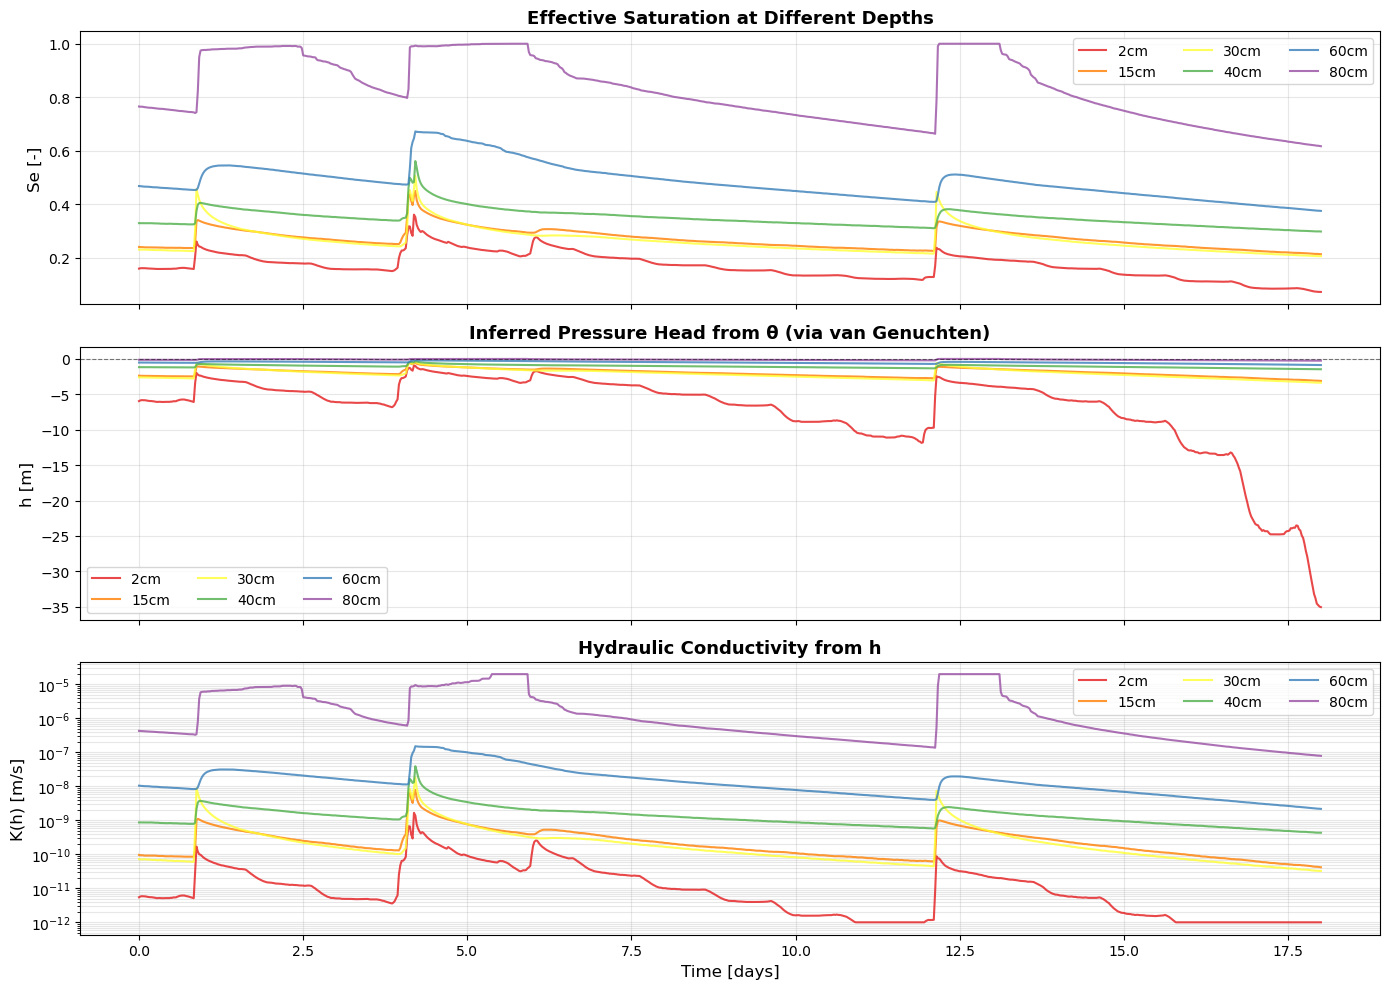


STATISTICS BY DEPTH

2cm:
  Se range:    0.0716 - 0.3607
  h range:     -35.0513 - -0.9388 m
  K range:     2.148e-14 - 1.664e-09 m/s
  Data points: 865

15cm:
  Se range:    0.2128 - 0.4492
  h range:     -3.1013 - -0.5607 m
  K range:     4.162e-11 - 7.844e-09 m/s
  Data points: 865

30cm:
  Se range:    0.2053 - 0.5054
  h range:     -3.3584 - -0.4202 m
  K range:     3.248e-11 - 1.825e-08 m/s
  Data points: 865

40cm:
  Se range:    0.2976 - 0.5611
  h range:     -1.4578 - -0.3215 m
  K range:     4.317e-10 - 3.903e-08 m/s
  Data points: 865

60cm:
  Se range:    0.3747 - 0.6720
  h range:     -0.8600 - -0.1932 m
  K range:     2.172e-09 - 1.513e-07 m/s
  Data points: 865

80cm:
  Se range:    0.6167 - 1.0000
  h range:     -0.2487 - 0.0000 m
  K range:     7.868e-08 - 2.000e-05 m/s
  Data points: 865


In [211]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, depth_name in enumerate(depth_names):
    if depth_name in all_results:
        data = all_results[depth_name]
        axes[0].plot(data['t_days'], data['Se'], color=colors[i],
                    label=depth_name, linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Se [-]', fontsize=12)
axes[0].set_title('Effective Saturation at Different Depths', fontsize=13, fontweight='bold')
axes[0].legend(ncol=3, fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)

for i, depth_name in enumerate(depth_names):
    if depth_name in all_results:
        data = all_results[depth_name]
        axes[1].plot(data['t_days'], data['h'], color=colors[i],
                    label=depth_name, linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('h [m]', fontsize=12)
axes[1].set_title('Inferred Pressure Head from θ (via van Genuchten)', fontsize=13, fontweight='bold')
axes[1].axhline(0.0, color='k', linewidth=0.8, alpha=0.5, linestyle='--')
axes[1].legend(ncol=3, fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)

for i, depth_name in enumerate(depth_names):
    if depth_name in all_results:
        data = all_results[depth_name]
        axes[2].semilogy(data['t_days'], np.maximum(data['K'], 1e-12),
                        color=colors[i], label=depth_name, linewidth=1.5, alpha=0.8)
axes[2].set_ylabel('K(h) [m/s]', fontsize=12)
axes[2].set_title('Hydraulic Conductivity from h', fontsize=13, fontweight='bold')
axes[2].legend(ncol=3, fontsize=10, loc='best')
axes[2].grid(True, which='both', alpha=0.3)
axes[2].set_xlabel('Time [days]', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("STATISTICS BY DEPTH")
print("="*70)
for depth_name in depth_names:
    if depth_name in all_results:
        data = all_results[depth_name]
        print(f"\n{depth_name}:")
        print(f"  Se range:    {data['Se'].min():.4f} - {data['Se'].max():.4f}")
        print(f"  h range:     {data['h'].min():.4f} - {data['h'].max():.4f} m")
        print(f"  K range:     {data['K'].min():.3e} - {data['K'].max():.3e} m/s")
        print(f"  Data points: {len(data['t_days'])}")
print("="*70)

In [212]:
print("\n" + "="*70)
print("STEP 5: PREPARING INITIAL CONDITION PROFILE")
print("="*70)

ic_depths = []
ic_theta = []

depth_mapping = {
    '2cm': (0.02, theta_2cm),
    '15cm': (0.15, theta_15cm),
    '30cm': (0.30, theta_30cm),
    '40cm': (0.40, theta_40cm),
    '60cm': (0.60, theta_60cm),
    '80cm': (0.80, theta_80cm),
}

print(f"Extracting initial moisture values at t=0:")
for depth_name, (depth_m, theta_series) in depth_mapping.items():
    valid_mask = ~pd.isna(theta_series)
    if valid_mask.any():
        if isinstance(theta_series, pd.Series):
            theta_ic = theta_series[valid_mask].iloc[0]
        else:
            theta_ic = theta_series[valid_mask][0]
        ic_depths.append(depth_m)
        ic_theta.append(theta_ic)
        print(f"  {depth_name:6s}: θ = {theta_ic:.4f} m³/m³")

ic_profile = {
    'depths': ic_depths,
    'theta': ic_theta
}

print(f"\n✓ IC Profile: {len(ic_depths)} measurement points")
print(f"  Will use IC type: {config.ic_type} (from config)")


STEP 5: PREPARING INITIAL CONDITION PROFILE
Extracting initial moisture values at t=0:
  2cm   : θ = 0.1151 m³/m³
  15cm  : θ = 0.1484 m³/m³
  30cm  : θ = 0.1443 m³/m³
  40cm  : θ = 0.1848 m³/m³
  60cm  : θ = 0.2417 m³/m³
  80cm  : θ = 0.3637 m³/m³

✓ IC Profile: 6 measurement points
  Will use IC type: obs (from config)


In [213]:
print("\n" + "="*70)
print("STEP 6: SAVING PREPROCESSED DATA FOR TRAINING")
print("="*70)

preprocessed_data = {
    'theta0_times': theta0_times_np,
    'theta0_values': theta0_values_np,
    'theta_2cm': theta_2cm,
    'theta_15cm': theta_15cm,
    'theta_30cm': theta_30cm,
    'theta_40cm': theta_40cm,
    'theta_60cm': theta_60cm,
    'theta_80cm': theta_80cm,
    'times_seconds': times_seconds,
    'datetime_col': datetime_col,
    'ic_profile': ic_profile,
    'config_file': config.config_path,
    'date_range': f"{config.start_date} to {config.end_date}",
}

output_file = '../data/preprocessed_soil_data.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(preprocessed_data, f)

print(f"✓ Preprocessed data saved to: {output_file}")
print(f"  Surface BC: {len(theta0_times_np)} points")
print(f"  All depths: 2cm, 15cm, 30cm, 40cm, 60cm, 80cm")
print(f"  IC profile: {len(ic_depths)} depths")
print(f"  Config: {config.config_path}")
print(f"  Date range: {config.start_date} to {config.end_date}")
print("\n✓ Ready for training! Run:")
print(f"  python hpc/train_with_config.py --config {config.config_path.replace('../', '')}")
print("="*70)


STEP 6: SAVING PREPROCESSED DATA FOR TRAINING
✓ Preprocessed data saved to: ../data/preprocessed_soil_data.pkl
  Surface BC: 865 points
  All depths: 2cm, 15cm, 30cm, 40cm, 60cm, 80cm
  IC profile: 6 depths
  Config: ../configs/baseline.yaml
  Date range: 2017-05-1 to 2017-05-19

✓ Ready for training! Run:
  python hpc/train_with_config.py --config configs/baseline.yaml
